In [60]:
import pandas as pd
import sys

sys.path.append("../")

df = pd.read_csv(
    "../dataset/hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,...,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Loan_to_Annual_Income,Customer_Sentiment,State,Occupation
0,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,...,Friend,30391,Public,KOL-004,No,Yes,11.747,Positive,Delhi,Farmer
1,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,...,Sibling,1856,Startup,DEL-001,No,Yes,40.381,Negative,Punjab,Civil Engineer
2,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,...,Unknown,24557,Private,BLR-003,Yes,Yes,3.082,Positive,Maharashtra,Medical Representative
3,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,...,Friend,36750,Startup,KOL-004,Yes,Yes,0.621,Negative,Gujarat,Marketing Executive
4,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,...,Parent,3920,Public,BLR-003,Yes,Yes,1.736,Neutral,West Bengal,Shopkeeper


In [61]:
df["Loan_Amount"].describe()

count    1.000000e+03
mean     2.216713e+06
std      2.635021e+06
min      1.884000e+03
25%      3.729465e+05
50%      9.720460e+05
75%      3.315038e+06
max      1.379096e+07
Name: Loan_Amount, dtype: float64

In [62]:
features = [
    "Applicant_Income",
    "Annual_Household_Income",
    "Asset_Value",
    "Existing_EMIs",
    "Employment_Length_Years",
    "CIBIL_Score",
    "Monthly_Expense",
    "Debt_to_Income_Ratio",
    "Loan_Term_Months",
    "Age",
    "Education",
    "Employment_Status",
    "Occupation",
    "Property_Area",
    "Purpose_of_Loan",
    "Married",
    "Dependents",
    "State"
]

In [63]:
from src.preprocessing import (
    encode_features,
    split_data,
    scale_data
)

In [64]:
X = encode_features(X)

print(X.shape)

(1000, 50)


In [65]:
X_train, X_test, y_train, y_test = split_data(
    X,
    y
)

print(X_train.shape)
print(X_test.shape)

(800, 50)
(200, 50)


In [66]:
X_train_scaled, X_test_scaled, scaler = scale_data(
    X_train,
    X_test
)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(800, 50)
(200, 50)


In [67]:
import importlib
import src.train

importlib.reload(src.train)

train.py loaded


<module 'src.train' from 'c:\\Users\\sujal\\OneDrive\\Desktop\\Aligned Automation\\Projects\\hdfc_ml_project\\notebooks\\..\\src\\train.py'>

In [68]:
from src.train import (
    train_linear_regression,
    train_random_forest_regressor,
    train_xgboost_regressor
)

In [69]:
linear_model = train_linear_regression(
    X_train_scaled,
    y_train
)

rf_model = train_random_forest_regressor(
    X_train,
    y_train
)

xgb_model = train_xgboost_regressor(
    X_train,
    y_train
)

print("Regression models trained successfully")

Regression models trained successfully


In [70]:
import importlib
import src.evaluate

importlib.reload(src.evaluate)

evaluate.py loaded


<module 'src.evaluate' from 'c:\\Users\\sujal\\OneDrive\\Desktop\\Aligned Automation\\Projects\\hdfc_ml_project\\notebooks\\..\\src\\evaluate.py'>

In [71]:
from src.evaluate import evaluate_regression_model
linear_results = evaluate_regression_model(
    linear_model,
    X_test_scaled,
    y_test
)

rf_results = evaluate_regression_model(
    rf_model,
    X_test,
    y_test
)

xgb_results = evaluate_regression_model(
    xgb_model,
    X_test,
    y_test
)

In [72]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Linear Regression": linear_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
})

comparison_df

,Linear Regression,Random Forest,XGBoost
MAE,1.132490e+06,1.096051e+06,1.238555e+06
MSE,3.005091e+12,3.332677e+12,3.944228e+12
RMSE,1.733520e+06,1.825562e+06,1.986008e+06
R2,5.048271e-01,4.508480e-01,3.500779e-01


In [74]:
import importlib
import src.train

importlib.reload(src.train)

train.py loaded


<module 'src.train' from 'c:\\Users\\sujal\\OneDrive\\Desktop\\Aligned Automation\\Projects\\hdfc_ml_project\\notebooks\\..\\src\\train.py'>

In [75]:
from src.train import tune_random_forest_regressor
rf_grid = tune_random_forest_regressor(
    X_train,
    y_train
)

In [76]:
print("Best Parameters:")
print(rf_grid.best_params_)

print()

print("Best R2 Score:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best R2 Score:
0.5824238814622449


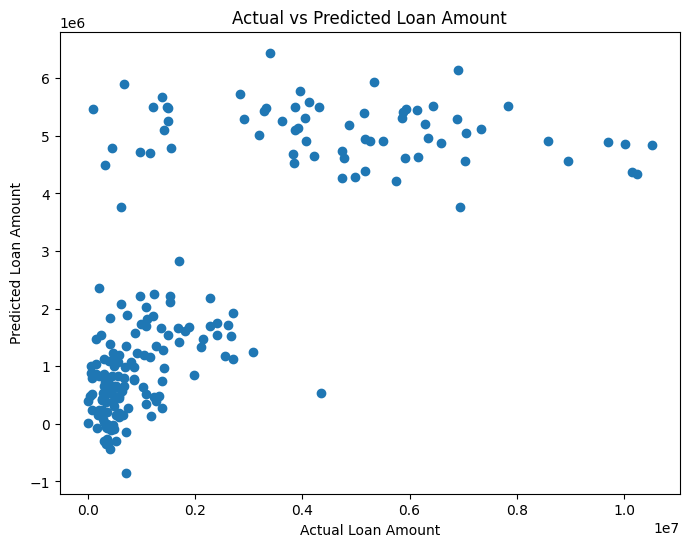

In [77]:
import matplotlib.pyplot as plt

y_pred = linear_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")

plt.savefig(
    "../visuals/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

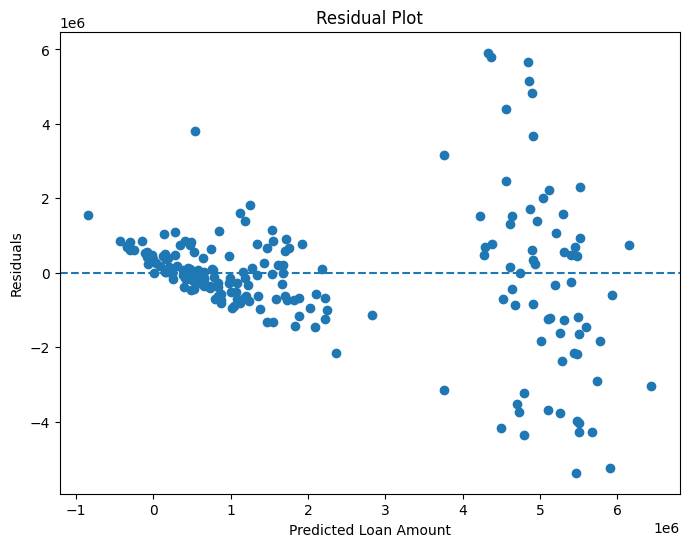

In [78]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig(
    "../visuals/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance_df.head(10)

top10

,Feature,Importance
36,Purpose_of_Loan_Home,0.571194
5,CIBIL_Score,0.045028
3,Existing_EMIs,0.042470
9,Age,0.040210
2,Asset_Value,0.026378
0,Applicant_Income,0.026323
6,Monthly_Expense,0.024509
4,Employment_Length_Years,0.022758
34,Purpose_of_Loan_Business,0.021691
1,Annual_Household_Income,0.021235


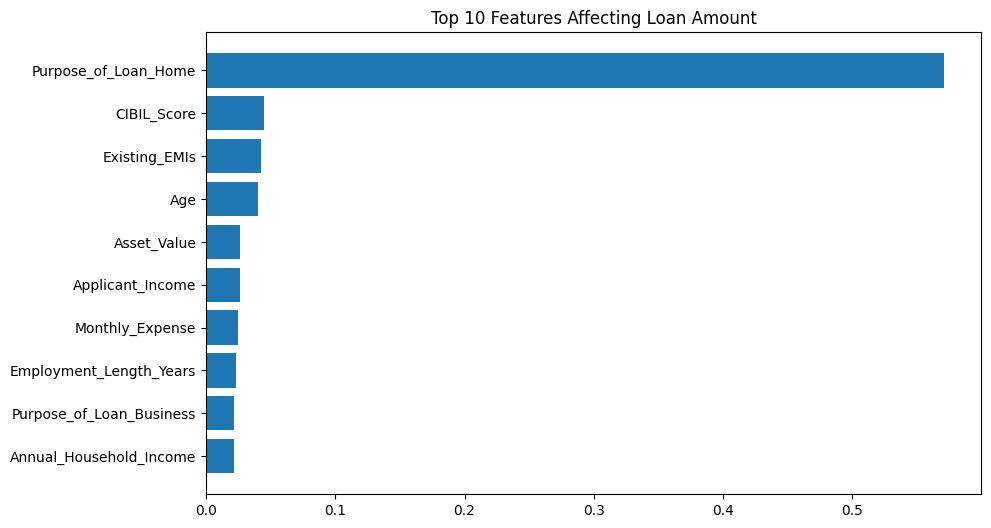

In [80]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features Affecting Loan Amount")

plt.savefig(
    "../visuals/loan_amount_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
import joblib

joblib.dump(
    linear_model,
    "../models/loan_amount_model.pkl"
)

print("Loan Amount Model Saved")

Loan Amount Model Saved
